# 05 — Finance Insights: Synthesis

Pulls the revenue funnel and headline KPIs together into one view. Full
narrative write-up (Observation / Impact / Cause / Action for each finding)
is in `docs/business_insights.md`; the CFO-level one-pager is
`docs/executive_summary.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR_PRIMARY = "#2A5CA6"
COLOR_RISK = "#C0392B"
COLOR_WARN = "#D68910"
COLOR_OK = "#2E8B57"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


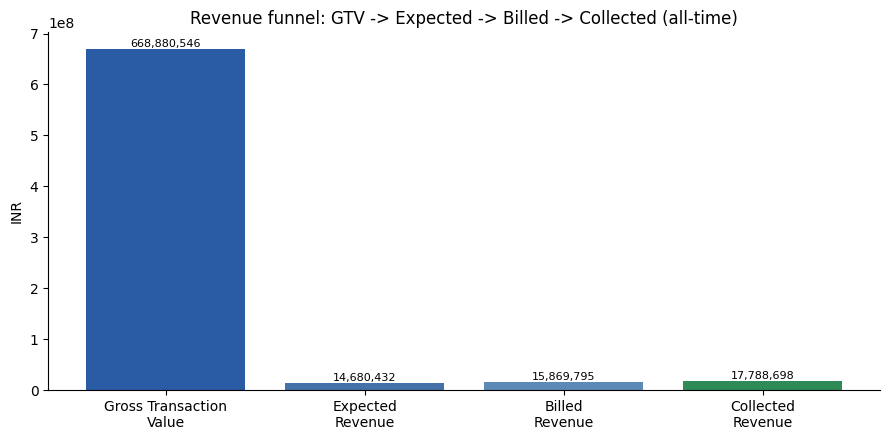

Realization rate (all-time): 112.09% (above 100% flags a payment-intake control gap - see insight #7, not over-performance)
Billing accuracy: 91.41%


In [2]:
overall = pd.read_csv(PROCESSED / "revenue_realization_overall.csv").iloc[0]
funnel_labels = ["Gross Transaction\nValue", "Expected\nRevenue", "Billed\nRevenue", "Collected\nRevenue"]
funnel_values = [overall["gross_transaction_value"], overall["expected_revenue"],
                  overall["billed_revenue"], overall["collected_revenue"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(funnel_labels, funnel_values, color=[COLOR_PRIMARY, "#4472A8", "#5C89B5", COLOR_OK])
ax.set_ylabel("INR")
ax.set_title("Revenue funnel: GTV -> Expected -> Billed -> Collected (all-time)")
for i, v in enumerate(funnel_values):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Realization rate (all-time): {overall['realization_rate_percent']}% "
      "(above 100% flags a payment-intake control gap - see insight #7, not over-performance)")
print(f"Billing accuracy: {overall['billing_accuracy_percent']}%")

## Where should Finance focus first?

In [3]:
priority_table = pd.DataFrame([
    ["1", "Duplicate/orphaned payment cleanup (control gap)", "Overstates realized revenue by >=INR 21 lakh"],
    ["2", "Failed Payment leakage recovery track", "INR 3.26 lakh, largest leakage category"],
    ["3", "90+ day AR back-book (churned-merchant escalation)", "INR 23.4 lakh, 81% of open AR"],
    ["4", "Missing Invoice monthly gate", "INR 2.51 lakh, 100% unbilled"],
    ["5", "Collection channel reallocation (Email -> WhatsApp/Phone)", "Efficiency gain, no new spend"],
], columns=["Priority", "Issue", "Financial stake"]).set_index("Priority")
priority_table

,Issue,Financial stake
Priority,,
1,Duplicate/orphaned payment cleanup (control gap),Overstates realized revenue by >=INR 21 lakh
2,Failed Payment leakage recovery track,"INR 3.26 lakh, largest leakage category"
3,90+ day AR back-book (churned-merchant escalat...,"INR 23.4 lakh, 81% of open AR"
4,Missing Invoice monthly gate,"INR 2.51 lakh, 100% unbilled"
5,Collection channel reallocation (Email -> What...,"Efficiency gain, no new spend"


## Closing

This notebook is a synthesis view — the full quantified writeup for every
finding above (with Observation / Financial Impact / Likely Cause /
Recommended Action) is in `docs/business_insights.md`, and the CFO-ready
one-page version is `docs/executive_summary.md`. Every number here is
reproducible by re-running the pipeline described in the README's
Installation section.